Transformer from Scratch: End-to-End Notebook (Basic to Advanced)
# Task: Machine Translation (e.g., English to French)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set seed for reproducibility
torch.manual_seed(42)

In [3]:
# Input Example
sentence = "The cat sat on the mat"  # Define an example input sentence as a string

# Create a vocabulary dictionary mapping each unique word to a unique index
vocab = {word: i for i, word in enumerate(set(sentence.lower().split()))}

# Compute the size of the vocabulary (number of unique words)
vocab_size = len(vocab)

# Convert the sentence into a list of indices using the vocab, then wrap it in a tensor
# The sentence is first lowercased and split into words; each word is mapped to its index
input_ids = torch.tensor([[vocab[word] for word in sentence.lower().split()]])

# Print the resulting tensor of input IDs
print("Input IDs:", input_ids)


Input IDs: tensor([[2, 1, 3, 0, 2, 4]])


In [4]:
embedding_dim = 16  # Dimensionality of embeddings

embedding = nn.Embedding(vocab_size, embedding_dim)
embed_output = embedding(input_ids)

print("Word Embeddings Shape:", embed_output.shape)
print("Word Embeddings Tensor:\n", embed_output)


Word Embeddings Shape: torch.Size([1, 6, 16])
Word Embeddings Tensor:
 tensor([[[-1.3847, -0.8712, -0.2234,  1.7174,  0.3189, -0.4245,  0.3057,
          -0.7746, -1.5576,  0.9956, -0.8798, -0.6011, -1.2742,  2.1228,
          -1.2347, -0.4879],
         [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,
           1.6806,  1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418,
          -0.2516,  0.8599],
         [-0.9138, -0.6581,  0.0780,  0.5258, -0.4880,  1.1914, -0.8140,
          -0.7360, -1.4032,  0.0360, -0.0635,  0.6756, -0.0978,  1.8446,
          -1.1845,  1.3835],
         [ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431,
          -1.6047, -0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594,
          -0.7688,  0.7624],
         [-1.3847, -0.8712, -0.2234,  1.7174,  0.3189, -0.4245,  0.3057,
          -0.7746, -1.5576,  0.9956, -0.8798, -0.6011, -1.2742,  2.1228,
          -1.2347, -0.4879],
         [ 1.4451,  0.8564,  2.2181,  0.5232,  0.3466,

In [5]:
embedding_dim = 16  # Set the dimensionality of the word embeddings (each word will be mapped to a 16-dimensional vector)

# Create an embedding layer that learns a lookup table of shape (vocab_size x embedding_dim)
embedding = nn.Embedding(vocab_size, embedding_dim)

# Pass the input word indices through the embedding layer to get their vector representations
embed_output = embedding(input_ids)

# Print the shape of the resulting embeddings; expected shape is (batch_size, sequence_length, embedding_dim)
print("Word Embeddings Shape:", embed_output.shape)


Word Embeddings Shape: torch.Size([1, 6, 16])


In [6]:
class PositionalEncoding(nn.Module):  # Define a custom PyTorch module for positional encoding
    def __init__(self, d_model, max_len=5000):  # d_model is the embedding size, max_len is max sequence length
        super().__init__()  # Call the parent constructor (nn.Module)

        pe = torch.zeros(max_len, d_model)  # Create a zero tensor of shape (max_len, d_model) for storing encodings

        position = torch.arange(0, max_len).unsqueeze(1).float()  # Shape: (max_len, 1); positions 0 to max_len-1


        # Compute frequency terms for sine/cosine based on dimension
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        # Apply sine to even dimensions
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd dimensions
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # Add a batch dimension → shape becomes (1, max_len, d_model)

        # Register 'pe' as a buffer (not a learnable parameter, but saved with model)
        self.register_buffer('pe', pe)


    def forward(self, x):
        # Add positional encoding to the input tensor
        # Slice self.pe to match the sequence length of x (x.size(1))
        # Adding directly leverages broadcasting for the batch dimension
        return x + self.pe[:, :x.size(1)]

Positional Encoded Embeddings Shape: torch.Size([1, 6, 16])
Positional Encoded Embeddings:
 tensor([[[-1.4570e+00,  8.9766e-01, -5.9915e-01,  1.4771e+00,  7.2618e-01,
           1.0912e+00, -3.8907e-01,  1.5279e+00, -1.2685e-02,  1.2408e+00,
           1.3254e-01,  1.7642e+00,  1.0950e+00,  1.3399e+00,  7.1997e-01,
           1.4114e+00],
         [-1.6681e+00,  1.0283e+00,  1.0956e+00,  9.7906e-01,  7.4059e-01,
           1.5783e+00,  1.0985e+00,  5.4935e-01, -1.7527e-01,  1.7527e+00,
           4.0792e-01,  1.1785e+00,  2.6591e-01,  2.2732e+00, -9.9464e-04,
           6.9640e-01],
         [ 2.8405e+00,  5.9572e-01, -8.4528e-01, -3.2328e-01,  6.2635e-02,
           2.6155e+00,  7.1794e-01,  1.5740e+00,  1.1615e+00,  1.0184e+00,
          -1.7995e+00,  1.9254e+00, -3.7334e-01,  2.0331e+00, -6.8602e-01,
           1.6368e+00],
         [ 1.5199e-01, -1.3287e+00, -5.2803e-01, -2.6169e-03,  8.3171e-01,
           1.4800e+00,  1.2359e+00,  1.0471e+00,  7.7395e-01,  5.1797e-01,
          -

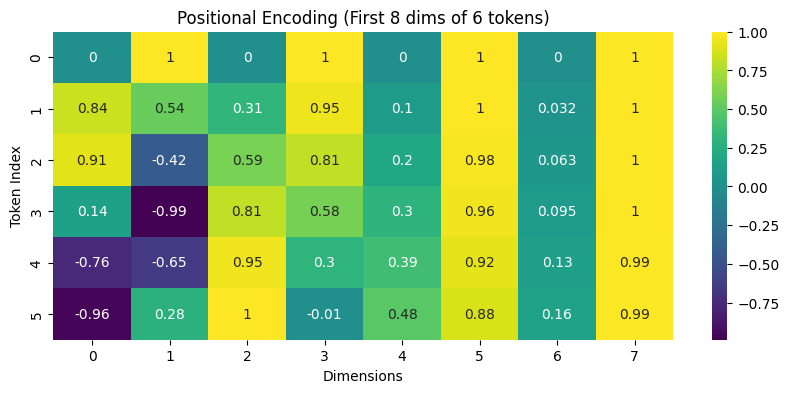

In [7]:
# Apply and visualize
pos_encoder = PositionalEncoding(embedding_dim)
pos_embed = pos_encoder(embed_output)
print("Positional Encoded Embeddings Shape:", pos_embed.shape)
print("Positional Encoded Embeddings:\n", pos_embed)

# Optional: Visualize first 8 dimensions of positional encodings
plt.figure(figsize=(10, 4))
sns.heatmap(pos_encoder.pe[0, :6, :8].detach().numpy(), annot=True, cmap='viridis')
plt.title("Positional Encoding (First 8 dims of 6 tokens)")
plt.xlabel("Dimensions")
plt.ylabel("Token Index")
plt.show()

In [13]:
class MultiHeadAttention(nn.Module):  # Define a PyTorch module for multi-head self-attention
    def __init__(self, embed_dim, num_heads):  # Takes total embedding size and number of attention heads
        super().__init__()
        assert embed_dim % num_heads == 0  # Ensure that the embedding can be evenly split across heads

        self.d_k = embed_dim // num_heads  # Dimension of each head (key/query/value)
        self.num_heads = num_heads  # Number of attention heads

        # Linear layers to project input embeddings to queries, keys, and values
        self.q_linear = nn.Linear(embed_dim, embed_dim)
        self.k_linear = nn.Linear(embed_dim, embed_dim)
        self.v_linear = nn.Linear(embed_dim, embed_dim)

        self.out = nn.Linear(embed_dim, embed_dim)  # Final linear layer after concatenating all heads

    def forward(self, q, k, v, mask=None):  # q, k, v are all (B, T, C) — batch, seq_len, embed_dim
        B, T_q, C = q.shape  # Get dimensions of the query input (T_q = target seq len)
        B_k, T_k, C_k = k.shape # Get dimensions of the key input (T_k = source seq len)
        # Note: Assuming B and C are the same for q, k, v after linear projections

        # Project and reshape for multi-head:
        # q: (B, T_q, C) → (B, num_heads, T_q, d_k)
        # k, v: (B, T_k, C_k) → (B, num_heads, T_k, d_k)
        q = self.q_linear(q).view(B, T_q, self.num_heads, self.d_k).transpose(1, 2)
        # Use T_k (key sequence length) for reshaping k and v
        k = self.k_linear(k).view(B_k, T_k, self.num_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(v).view(B_k, T_k, self.num_heads, self.d_k).transpose(1, 2)


        # Compute scaled dot-product attention: (B, num_heads, T_q, T_k) - q @ k.T
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)  # similarity between queries and keys

        if mask is not None:
            # Mask is applied to scores, which have shape (B, num_heads, T_q, T_k).
            # The mask should match the shape of scores or be broadcastable.
            # If mask is for self-attention (T_q == T_k), it's typically (1, T_q, T_q) or (B, 1, T_q, T_q)
            # If mask is for cross-attention, it's usually not needed unless masking encoder output (less common)
            # For the dummy forward pass, the mask is None, so this part is not the cause of the error.
            scores = scores.masked_fill(mask == 0, -1e9)  # Apply attention mask if provided

        weights = F.softmax(scores, dim=-1)  # Normalize to get attention weights (sums to 1 over T_k dimension)

        attn = weights @ v  # Apply attention weights to values → (B, num_heads, T_q, d_k)

        # Reshape back: (B, num_heads, T_q, d_k) → (B, T_q, C)
        # Use T_q for the final reshape as the output shape matches the query sequence length
        attn = attn.transpose(1, 2).contiguous().view(B, T_q, B * self.num_heads * self.d_k // B) # C should be B * num_heads * d_k / B == embed_dim
        # A simpler way to get C is from the original q shape: B, T_q, C = q.shape
        attn = attn.transpose(1, 2).contiguous().view(B, T_q, C)


        return self.out(attn)  # Final linear projection after concatenating all heads

# Define the toy MHA module (keep this for testing the MHA directly if desired)
mha = MultiHeadAttention(embed_dim=16, num_heads=2)
attn_out = mha(pos_embed, pos_embed, pos_embed)
print("MHA Output Shape:", attn_out.shape)
print("MHA Output Tensor:\n", attn_out)

MHA Output Shape: torch.Size([1, 6, 16])
MHA Output Tensor:
 tensor([[[-0.1222,  0.6008,  0.0519,  0.2521,  0.6375,  0.2512, -0.4806,
           0.9452,  0.6262,  0.0292,  0.8718,  0.2275, -0.1932,  0.0164,
           0.9303, -0.0159],
         [ 0.1216,  0.2626,  0.2084, -0.2385,  0.5931,  0.2063, -0.4066,
           0.0545,  0.5366, -0.0974,  0.0791,  0.6462,  0.4667,  0.0943,
           0.4933,  0.0389],
         [ 0.1846,  0.1695, -0.1851, -0.1105, -0.2671, -0.3187, -0.4381,
           0.3176, -0.4682,  0.4764, -0.3121, -0.0430,  0.0672, -0.9225,
           0.0102,  0.7461],
         [ 0.2624,  0.0648,  0.2697, -0.3287,  0.4087,  0.0806, -0.2482,
           0.3695,  0.0427,  0.0373,  0.2563,  0.1861,  0.2197,  0.0974,
           0.1170,  0.0472],
         [ 0.5343, -0.3521,  0.1284, -0.3456,  0.1751, -0.1749,  0.1094,
           0.3034, -0.4579, -0.2325,  0.8156, -0.2512,  0.0062,  0.0556,
          -0.1296, -0.4270],
         [ 0.2566,  0.1122,  0.1759, -0.2755,  0.2084, -0.0954, 

What just happened?
1. Input: 2 tokens, each with a 4-dimensional vector.
2. Split into 2 heads → each head processes 2-dimensional keys/queries/values.
3. Each head computes dot-product attention over the 2 tokens.
The attended values from each head are concatenated and passed through a final linear layer.

In [14]:
class FeedForward(nn.Module):  # Defines the position-wise feed-forward network (FFN)
    def __init__(self, embed_dim, ff_dim=64):  # embed_dim = input/output dimension, ff_dim = hidden layer size
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)  # First linear transformation (expansion)
        self.linear2 = nn.Linear(ff_dim, embed_dim)  # Second linear transformation (reduction)

    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))  # Apply ReLU after first linear layer, then second linear

mha_layer = MultiHeadAttention(embed_dim=embedding_dim, num_heads=2) # Use the correct embedding_dim and number of heads
attn_out = mha_layer(pos_embed, pos_embed, pos_embed) # Apply MHA to the positional encoded embeddings

# Apply on attention output
ffn = FeedForward(embed_dim=16)
ffn_out = ffn(attn_out)
print("Feed Forward Output Shape:", ffn_out.shape)
print("Feed Forward Output:\n", ffn_out)

Feed Forward Output Shape: torch.Size([1, 6, 16])
Feed Forward Output:
 tensor([[[ 0.0938, -0.0523,  0.0592,  0.0248,  0.0507,  0.1211,  0.1785,
           0.1869,  0.0773,  0.0166, -0.0969,  0.1728, -0.1038, -0.1011,
           0.1677, -0.0354],
         [ 0.0992,  0.0412,  0.0934,  0.0767, -0.0228,  0.1742,  0.0842,
          -0.0320,  0.0540,  0.0207, -0.1265,  0.0965, -0.0291, -0.0571,
           0.0902,  0.0739],
         [ 0.1623,  0.0631, -0.0352,  0.0270, -0.0618,  0.0495,  0.0936,
           0.1201,  0.0113, -0.0007, -0.1270,  0.0183, -0.0533,  0.0011,
           0.1326, -0.0381],
         [ 0.1616,  0.0838, -0.0464,  0.0050,  0.0256,  0.1157,  0.2537,
           0.1566,  0.0347, -0.0204, -0.1325,  0.1416, -0.0972, -0.1134,
           0.1773, -0.0882],
         [ 0.1114,  0.0697,  0.0490,  0.1438, -0.1345,  0.2061,  0.1998,
          -0.0257, -0.0414, -0.0518, -0.0656, -0.0040,  0.0439, -0.0960,
           0.1379,  0.0911],
         [ 0.1291, -0.0741,  0.0712,  0.0686,  0.0842

In [18]:
class EncoderLayer(nn.Module):  # Represents one Transformer encoder layer block
    def __init__(self, embed_dim, num_heads):
        super().__init__()

        self.mha = MultiHeadAttention(embed_dim, num_heads)  # Multi-head self-attention layer
        self.norm1 = nn.LayerNorm(embed_dim)  # First LayerNorm after self-attention
        self.ff = FeedForward(embed_dim)  # Position-wise feedforward block
        self.norm2 = nn.LayerNorm(embed_dim)  # Second LayerNorm after feedforward block

    def forward(self, x):
        x2 = self.mha(x, x, x)             # Self-attention output: shape (B, T, embed_dim)
        x = self.norm1(x + x2)             # Residual connection + LayerNorm (1st sublayer)

        x2 = self.ff(x)                    # Feedforward transformation
        return self.norm2(x + x2)          # Residual connection + LayerNorm (2nd sublayer)

# Test one encoder layer
encoder_layer = EncoderLayer(embed_dim=16, num_heads=2)
enc_layer_out = encoder_layer(pos_embed)
print("Encoder Layer Output Shape:", enc_layer_out.shape)
print("Encoder Layer Output:\n", enc_layer_out)

Encoder Layer Output Shape: torch.Size([1, 6, 16])
Encoder Layer Output:
 tensor([[[-1.5161,  0.6484, -1.8096,  0.9690,  0.3698,  0.6713, -1.2244,
           0.8925, -1.7336,  0.7884, -0.6169,  0.9619,  0.5266, -0.2266,
           0.4514,  0.8479],
         [-2.3842,  0.7600, -0.2423,  0.5040, -0.0093,  0.2839,  0.4558,
          -0.4000, -1.3341,  1.3440,  0.3371,  0.4186, -0.5879,  1.8530,
          -1.1411,  0.1424],
         [ 1.3576,  0.3189, -1.7439, -0.8470, -0.3103,  1.2056,  0.1706,
          -0.0563,  0.7069,  0.5776, -1.8669,  0.4093, -0.9988,  1.0764,
          -1.0176,  1.0179],
         [-0.3088, -1.4560, -0.6761, -0.1651,  0.5928,  1.0022,  0.9196,
           0.6988,  0.7368,  0.4990, -1.0926,  0.2351, -2.3351, -0.8402,
           1.0129,  1.1767],
         [-2.3848, -1.1857, -0.6370,  0.3387,  1.4990,  0.5308, -0.6500,
           0.6052, -1.2593,  1.0111, -0.2708,  1.0570,  0.3724,  0.7347,
          -0.4113,  0.6499],
         [-0.9001,  0.5999,  1.8322,  0.6033,  0.65

In [38]:
class Encoder(nn.Module):  # Full Transformer Encoder stack with embedding, positional encoding, and N encoder layers
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers):
        super().__init__()

        # Learnable word embedding layer
        self.embed = nn.Embedding(vocab_size, embed_dim)

        # Fixed positional encodings added to token embeddings
        self.pos_encoder = PositionalEncoding(embed_dim)

        # Stack of EncoderLayers (multi-head attention + FFN + residual + norm)
        self.layers = nn.ModuleList([EncoderLayer(embed_dim, num_heads) for _ in range(num_layers)])

    def forward(self, x, src_mask=None):  # x is (batch_size, seq_len)
        x = self.embed(x)  # Convert word indices to embeddings → shape: (B, T, embed_dim)
        x = self.pos_encoder(x)  # Add positional information to embeddings

        for layer in self.layers:  # Pass through each EncoderLayer
            x = layer(x)

        return x  # Final encoded representations (contextual embeddings)

# Create an encoder with:
# - vocab_size = number of unique tokens
# - embedding_dim = dimension of word embeddings
# - 2 heads per attention layer
# - 2 encoder layers stacked
# Build encoder
encoder = Encoder(vocab_size, embedding_dim, num_heads=2, num_layers=2)
encoder_out = encoder(input_ids)
print("Encoder Output Shape:", encoder_out.shape)
print("Encoder Output Tensor:\n", encoder_out)


Encoder Output Shape: torch.Size([1, 6, 32])
Encoder Output Tensor:
 tensor([[[-1.1024e+00, -8.6647e-01, -1.6215e+00,  1.6862e+00, -3.4951e-01,
           1.3291e-01,  2.3808e-01,  1.5017e+00, -1.0178e+00, -2.8267e-01,
           4.8902e-01,  1.6348e+00, -1.4259e+00,  1.3682e+00, -1.3874e+00,
           3.9933e-02,  2.4492e-02, -7.0489e-02, -3.8915e-01,  1.9464e-02,
           6.3973e-01,  4.9879e-01,  7.7992e-01,  8.0021e-01, -8.2833e-01,
           2.4606e-01, -1.6331e+00,  9.3519e-01, -1.3655e+00,  1.8836e+00,
           1.0974e-01, -6.8779e-01],
         [ 1.5734e+00,  3.0860e-01, -7.3993e-01,  2.9056e-01, -2.3029e-01,
           1.0898e+00,  2.9271e-01,  4.8320e-01, -7.4616e-01, -1.7342e+00,
           5.8612e-01,  8.3079e-01, -2.1086e+00,  2.4085e-01, -1.5116e+00,
           1.3727e+00,  2.0621e-01,  6.3307e-01,  1.0763e+00,  1.2125e+00,
          -1.0454e-01,  3.9548e-01,  2.5874e-01, -5.8384e-01, -1.8245e+00,
           3.6074e-01, -1.6496e+00,  1.0644e+00, -2.8997e-01, -1.3283

In [39]:
class DecoderLayer(nn.Module):  # A single decoder layer in the Transformer decoder stack
    def __init__(self, embed_dim, num_heads):
        super().__init__()

        self.self_attn = MultiHeadAttention(embed_dim, num_heads)
        # Masked self-attention for the decoder (can't attend to future tokens)

        self.cross_attn = MultiHeadAttention(embed_dim, num_heads)
        # Cross-attention: decoder attends to encoder output

        self.norm1 = nn.LayerNorm(embed_dim)  # LayerNorm after self-attention
        self.norm2 = nn.LayerNorm(embed_dim)  # LayerNorm after cross-attention
        self.ff = FeedForward(embed_dim)      # Feedforward sublayer
        self.norm3 = nn.LayerNorm(embed_dim)  # LayerNorm after feedforward

    def forward(self, x, enc_out, tgt_mask=None):
        # x: target sequence input (B, T, E)
        # enc_out: encoder outputs (B, S, E)
        # tgt_mask: attention mask to prevent peeking at future tokens (optional)
        x2 = self.self_attn(x, x, x, mask=tgt_mask)
        # Masked self-attention: attends to earlier positions in target only

        x = self.norm1(x + x2)
        # Residual + LayerNorm
        x2 = self.cross_attn(x, enc_out, enc_out)
        # Cross-attention: query is the decoder output so far, key/value come from encoder

        x = self.norm2(x + x2)
        # Residual + LayerNorm
        x2 = self.ff(x)
        # Position-wise feedforward network

        return self.norm3(x + x2)
        # Final Residual + LayerNorm


In [40]:
def generate_square_subsequent_mask(sz):
    # Creates an upper-triangular matrix of -inf, with 0s on the diagonal
    mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
    return mask  # Shape: (sz, sz)


In [41]:
class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.self_attn = MultiHeadAttention(embed_dim, num_heads)  # Masked Self-Attention
        self.norm1 = nn.LayerNorm(embed_dim)

        self.cross_attn = MultiHeadAttention(embed_dim, num_heads)  # Cross-Attention with Encoder Output
        self.norm2 = nn.LayerNorm(embed_dim)

        self.ff = FeedForward(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)

    def forward(self, x, enc_out, tgt_mask=None):
        # x: decoder input (B, T_dec, E)
        # enc_out: encoder output (B, T_enc, E)

        # ---- 1. Masked self-attention over decoder input ----
        x2 = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + x2)  # Add & Norm

        # ---- 2. Cross-attention with encoder outputs ----
        x2 = self.cross_attn(x, enc_out, enc_out)  # Queries from decoder, Keys/Values from encoder
        x = self.norm2(x + x2)

        # ---- 3. Feed-forward network ----
        x2 = self.ff(x)
        x = self.norm3(x + x2)

        return x  # Final output shape: (B, T_dec, E)


In [42]:
class Decoder(nn.Module):  # Defines a full Transformer Decoder
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        # Converts target token IDs into embeddings of size (embed_dim)

        self.pos_encoder = PositionalEncoding(embed_dim)
        # Adds fixed sinusoidal positional encodings to each token embedding

        self.layers = nn.ModuleList([
            DecoderLayer(embed_dim, num_heads) for _ in range(num_layers)
        ])
        # Stack N decoder layers for depth and expressiveness

        self.out = nn.Linear(embed_dim, vocab_size)
        # Maps the final decoder output back to vocabulary space (logits)

    def forward(self, x, enc_out, tgt_mask=None):
        # x: Target input tokens → (B, T_dec)
        # enc_out: Encoder output → (B, T_enc, E)
        # tgt_mask: Causal mask for decoder self-attention

        x = self.embed(x)
        # Convert token IDs into dense vectors → (B, T_dec, E)

        x = self.pos_encoder(x)
        # Add positional encoding to retain sequence order → (B, T_dec, E)

        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask)
        # Pass through each DecoderLayer: masked self-attn, cross-attn, FFN

        return self.out(x)
        # Final output: vocabulary logits for each position → (B, T_dec, vocab_size)


In [43]:
# Let's say the target sentence is "cat sat"
target_sentence = "cat sat"
target_ids = torch.tensor([[vocab[word] for word in target_sentence.split()]])
print("Target IDs:", target_ids)

# Create a target mask to prevent attention to future positions
tgt_mask = generate_square_subsequent_mask(target_ids.size(1))
print("Target Mask:\n", tgt_mask)

# Build Decoder
decoder = Decoder(vocab_size, embedding_dim, num_heads=2, num_layers=2)

# Run Decoder
decoder_output = decoder(target_ids, encoder_out, tgt_mask=tgt_mask)

print("Decoder Output Shape:", decoder_output.shape)
print("Decoder Output (Logits):\n", decoder_output)


Target IDs: tensor([[1, 3]])
Target Mask:
 tensor([[False,  True],
        [False, False]])
Decoder Output Shape: torch.Size([1, 2, 5])
Decoder Output (Logits):
 tensor([[[ 0.5885,  0.0590, -0.6416,  0.3131,  0.4442],
         [ 0.5513,  0.6719, -0.9935,  0.0403, -0.0717]]],
       grad_fn=<ViewBackward0>)


In [44]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, embed_dim, num_heads, num_layers):
        super().__init__()
        self.encoder = Encoder(src_vocab, embed_dim, num_heads, num_layers)
        self.decoder = Decoder(tgt_vocab, embed_dim, num_heads, num_layers)

    def forward(self, src, tgt, tgt_mask=None):
        enc_out = self.encoder(src)
        return self.decoder(tgt, enc_out, tgt_mask)

# Dummy Forward Pass for Translation
src_ids = input_ids
# Assuming target has <sos> and dummy words like ["<sos>", "le", "chat"]
tgt_vocab = vocab_size + 5
tgt_ids = torch.tensor([[0, 1, 2]])  # e.g., dummy French translation
model = Transformer(vocab_size, tgt_vocab, embedding_dim, 2, 2)
logits = model(src_ids, tgt_ids)
print("Logits Shape:", logits.shape)  # (batch_size, tgt_seq_len, tgt_vocab)
print("Logits:\n", logits)


Logits Shape: torch.Size([1, 3, 10])
Logits:
 tensor([[[-0.2255,  1.0245, -0.0692,  0.5211, -0.4707, -0.6119, -0.8070,
           0.4447, -0.9420,  1.2127],
         [-0.6317, -0.1067,  1.1268, -0.0413, -0.3810,  0.3777, -0.2432,
           0.2339, -0.9863,  0.2698],
         [-0.2031,  0.6008,  0.1377, -0.8626,  0.6298, -0.9097, -0.1635,
          -0.4371,  0.1148,  0.5426]]], grad_fn=<ViewBackward0>)


In [51]:
# Define source (English) vocabulary
src_word_list = ["<sos>", "the", "cat", "sat", "on", "the", "mat", "<eos>"]
# Create vocabulary from unique words in sorted order for consistent indexing
unique_src_words = sorted(list(set(src_word_list)))
src_word2idx = {word: i for i, word in enumerate(unique_src_words)}
src_idx2word = {i: word for word, i in src_word2idx.items()}
print("Source Vocab:", src_word2idx)

# Define target (French) vocabulary (example)
# You should define a vocabulary appropriate for your translation task
tgt_word_list = ["<sos>", "le", "chat", "est", "assis", "sur", "le", "tapis", "<eos>"]
# Create vocabulary from unique words in sorted order for consistent indexing
unique_tgt_words = sorted(list(set(tgt_word_list)))
tgt_word2idx = {word: i for i, word in enumerate(unique_tgt_words)}
tgt_idx2word = {i: word for word, i in tgt_word2idx.items()}

print("Target Vocab:", tgt_word2idx)

Source Vocab: {'<eos>': 0, '<sos>': 1, 'cat': 2, 'mat': 3, 'on': 4, 'sat': 5, 'the': 6}
Target Vocab: {'<eos>': 0, '<sos>': 1, 'assis': 2, 'chat': 3, 'est': 4, 'le': 5, 'sur': 6, 'tapis': 7}


In [52]:
src_sentence = "the cat sat on the mat"
src_tokens = ["<sos>"] + src_sentence.split() + ["<eos>"]

# Convert tokens to IDs using the corrected vocabulary
src_ids = torch.tensor([[src_word2idx[word] for word in src_tokens]])  # shape: (1, seq_len)
print("Source IDs:", src_ids)

Source IDs: tensor([[1, 6, 2, 5, 4, 6, 3, 0]])


In [54]:
# Let's say the target sentence is "le chat est assis sur le tapis"
# We need a target input for training (with <sos>, no <eos>) and target output (no <sos>, with <eos>)
tgt_sentence = "le chat est assis sur le tapis"
tgt_tokens_full = ["<sos>"] + tgt_sentence.split() + ["<eos>"]
tgt_ids_full = torch.tensor([[tgt_word2idx[word] for word in tgt_tokens_full]])
print("Target IDs Full:", tgt_ids_full)

Target IDs Full: tensor([[1, 5, 3, 4, 2, 6, 5, 7, 0]])


In [55]:
# Target input and output
tgt_input = tgt_ids_full[:, :-1]  # decoder input (with <sos>, no <eos>)
tgt_output = tgt_ids_full[:, 1:]  # expected output (no <sos>, with <eos>)
print("Target Input IDs:", tgt_input)
print("Target Output IDs:", tgt_output)

Target Input IDs: tensor([[1, 5, 3, 4, 2, 6, 5, 7]])
Target Output IDs: tensor([[5, 3, 4, 2, 6, 5, 7, 0]])


In [56]:
class Transformer(nn.Module):
    # Define the overall Transformer model that consists of both encoder and decoder modules.

    def __init__(self, src_vocab_size, tgt_vocab_size, embed_dim, num_heads, num_layers):
        """
        Initializes the Transformer model with encoder and decoder.

        Args:
            src_vocab_size (int): Size of the source language vocabulary.
            tgt_vocab_size (int): Size of the target language vocabulary.
            embed_dim (int): Dimensionality of token embeddings.
            num_heads (int): Number of attention heads in each multi-head attention block.
            num_layers (int): Number of encoder and decoder layers.
        """
        super().__init__()  # Call the constructor of nn.Module

        # Instantiate the encoder with its own embedding and layers
        self.encoder = Encoder(src_vocab_size, embed_dim, num_heads, num_layers)

        # Instantiate the decoder with target vocab, embedding, and layers
        self.decoder = Decoder(tgt_vocab_size, embed_dim, num_heads, num_layers)

    def forward(self, src, tgt):
        """
        Defines the forward pass of the Transformer.

        Args:
            src (Tensor): Source input tokens (batch_size, src_seq_len)
            tgt (Tensor): Target input tokens (batch_size, tgt_seq_len)

        Returns:
            Tensor: Output logits over target vocabulary (batch_size, tgt_seq_len, tgt_vocab_size)
        """
        src_mask = None
        # No source mask is applied here (but in real training, we may apply a padding mask)

        tgt_mask = generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        # Generate a causal mask for the target sequence to prevent peeking into future tokens.
        # Shape: (tgt_seq_len, tgt_seq_len)

        enc_out = self.encoder(src, src_mask)
        # Pass source tokens through the encoder to get contextualized source embeddings.
        # enc_out shape: (batch_size, src_seq_len, embed_dim)

        out = self.decoder(tgt, enc_out, tgt_mask)
        # Decode the target input tokens, attending to encoder outputs with cross-attention.
        # Output: logits over the target vocabulary at each time step

        return out
        # Return the final predictions (before softmax) — shape: (batch_size, tgt_seq_len, tgt_vocab_size)


In [57]:
embedding_dim = 32
vocab_size_src = len(src_word2idx)
vocab_size_tgt = len(tgt_word2idx)

model = Transformer(vocab_size_src, vocab_size_tgt, embedding_dim, 2, 2)


In [58]:
print("Src Vocab Size:", vocab_size_src)
print("Tgt Vocab Size:", vocab_size_tgt)

Src Vocab Size: 7
Tgt Vocab Size: 8


In [64]:
model = Transformer(vocab_size_src, vocab_size_tgt, embedding_dim, 2, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
src_ids = src_ids.to(device)
tgt_input = tgt_input.to(device)
tgt_output = tgt_output.to(device) # Move target output as well for loss calculation

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.train()
# Consider reducing epochs significantly if training on only one example
# It will overfit quickly. 5000 is excessive.
for epoch in range(500): # Reduced epochs for quick demonstration of overfitting
    optimizer.zero_grad()
    # The forward method handles device placement for the mask now
    logits = model(src_ids, tgt_input)  # (batch, tgt_len, vocab_size)

    # Reshape and calculate loss
    # tgt_output is already on the correct device
    loss = criterion(logits.view(-1, logits.size(-1)), tgt_output.view(-1))
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0: # Print less often
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 1.7652
Epoch 50: Loss = 0.0455
Epoch 100: Loss = 0.0208
Epoch 150: Loss = 0.0121
Epoch 200: Loss = 0.0080
Epoch 250: Loss = 0.0057
Epoch 300: Loss = 0.0043
Epoch 350: Loss = 0.0033
Epoch 400: Loss = 0.0027
Epoch 450: Loss = 0.0022


Here are potential reasons that might arise in this, especially after training on a single, very short sentence pair:

1. Lack of Sufficient/Diverse Training Data: You've trained the model on only one sentence pair ("the cat sat on the mat" -> "le chat est assis sur le tapis"). The model has learned a single translation example. It hasn't seen enough variety to generalize or learn the nuances of language generation beyond this specific instance. The "assis" token might have a strong association with the encoder's output for this particular input, or it might simply be a frequent word in your single target sentence that the model latched onto.
Overfitting to a Single Example: With just one example and potentially many training epochs (5000 in the original traceback, though reduced to 500 in your provided code), the model heavily overfits to the specific input-output pairing. It learns to map the source sequence to the target sequence, but when decoding starts with <sos>, it might quickly default to a token that frequently follows <sos> or is prominent in the target sentence, especially if the learned attention weights aren't perfectly aligned to generate the sequence step-by-step.

2. Small Model Size Relative to Task Complexity (Even for One Sentence): While the model architecture (Transformer) is powerful, the small embedding_dim (16 or 32) and limited number of layers (2) might still be insufficient to perfectly capture the sequential dependencies needed for generation, even for one sentence, when data is this scarce.
Training Instability: Although less likely with Adam and CrossEntropyLoss on a single tiny batch, issues like learning rate or initialization could potentially lead to unstable training where the model converges to a trivial or repetitive solution.

3. Issue with EOS Handling (Minor): While the greedy_decode function correctly checks for eos_idx, if the model never learns to output the <eos> token (because it's only seen in one specific position in the target output during training), it will continue decoding up to max_len, resulting in repetition if it gets stuck.
4. Random Chance / Initialization: In extremely low-data regimes, the initial random weights can heavily influence what the model learns. It might have randomly developed a strong bias towards predicting "assis".
In essence, the model hasn't learned "translation" as a concept; it has merely memorized a specific mapping from one sequence of indices to another, and when asked to generate step-by-step, it falls back to repeating a learned pattern, likely influenced by the single training example.

In [65]:
# Implement greedy decoding for inference
def greedy_decode(model, src, max_len=10, sos_idx=0, eos_idx=None):
    # Set the model to evaluation mode
    model.eval()
    # Disable gradient calculation for inference
    with torch.no_grad():
        # Pass the source input through the encoder
        # enc_out shape: (batch_size, src_seq_len, embed_dim)
        enc_out = model.encoder(src)

        # Initialize the target sequence with the start-of-sequence token (<sos>)
        # tgt shape: (batch_size, 1)
        # Ensure tgt is on the same device as src
        tgt = torch.tensor([[sos_idx]], device=src.device)

        # Loop to generate tokens up to max_len or until <eos> is predicted
        for _ in range(max_len):
            # Generate a causal mask for the current target sequence length
            # This mask prevents the decoder from attending to future tokens
            # Ensure the mask is on the same device as the target input
            tgt_mask = generate_square_subsequent_mask(tgt.size(1)).to(src.device)

            # Pass the current target sequence and encoder output through the decoder
            # out shape: (batch_size, current_tgt_seq_len, tgt_vocab_size)
            out = model.decoder(tgt, enc_out, tgt_mask)

            # Get the logits for the last token in the sequence
            # out[:, -1, :] shape: (batch_size, tgt_vocab_size)
            # Find the index (ID) of the token with the highest probability
            # next_token shape: (batch_size, 1)
            next_token = out[:, -1, :].argmax(dim=-1, keepdim=True)

            # Append the predicted next token to the target sequence
            # tgt shape: (batch_size, current_tgt_seq_len + 1)
            tgt = torch.cat([tgt, next_token], dim=1)

            # Check if the predicted token is the end-of-sequence token (<eos>)
            # If eos_idx is provided and the predicted token is <eos>, stop decoding
            if eos_idx is not None and next_token.item() == eos_idx:
                break

    # Return the complete predicted target sequence (including <sos> and potentially <eos>)
    return tgt

# --- Using the greedy_decode function ---

# Call the greedy_decode function with the trained model and source IDs
# Use the src_ids that were created using the correct vocabulary
# Need to pass the correct sos_idx and eos_idx based on the target vocabulary
# Assuming <sos> is index 0 and <eos> is the last index in the sorted target vocabulary
sos_idx_tgt = tgt_word2idx["<sos>"]
# Find the index of <eos> in the target vocabulary
eos_idx_tgt = tgt_word2idx.get("<eos>") # Use .get to handle cases where <eos> might be missing

decoded_ids = greedy_decode(model, src_ids.to(model.encoder.embed.weight.device), sos_idx=sos_idx_tgt, eos_idx=eos_idx_tgt)

# Convert the decoded token IDs back to words using the target index-to-word mapping
# decoded_ids[0] gets the sequence for the first item in the batch
decoded_sentence = [tgt_idx2word[idx.item()] for idx in decoded_ids[0]]

# Join the words to form the predicted French sentence
print("Predicted French Translation:", " ".join(decoded_sentence))

Predicted French Translation: <sos> assis assis assis assis assis assis assis assis assis assis


Lets check with some diverse training data

In [84]:
# Define source (English) and target (French) sentence pairs
train_data = [
    ("the cat sat on the mat", "le chat est assis sur le tapis"),
    ("the cat sat on the mat", "le chat est assis sur le tapis"),
    ("the cat sat on the mat", "le chat est assis sur le tapis"),
    ("the cat sat on the mat", "le chat est assis sur le tapis"),
    ("the cat sat on the mat", "le chat est assis sur le tapis"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("the dog ran in the park", "le chien a couru dans le parc"),
    ("a quick brown fox jumps over the lazy dog", "un renard brun rapide saute par-dessus le chien paresseux"),
    ("i love machine learning", "j'adore l'apprentissage automatique"),
    ("how are you today", "comment allez-vous aujourd'hui"),
    ("what is your name", "comment vous appelez-vous"),
    ("where do you live", "où habitez-vous"),
    ("thank you very much", "merci beaucoup"),
    ("please help me", "s'il vous plaît aidez-moi"),
    ("i do not understand", "je ne comprends pas"),
    ("can you speak slower", "pouvez-vous parler plus lentement"),
    ("what time is it", "quelle heure est-il"),
    ("i am hungry", "j'ai faim"),
    ("i am thirsty", "j'ai soif"),
    ("i am tired", "je suis fatigué"),
    ("i am happy", "je suis heureux"),
    ("i am sad", "je suis triste"),
    ("i am angry", "je suis en colère"),
    ("it is raining", "il pleut"),
    ("it is sunny", "il fait soleil"),
    ("it is cold", "il fait froid"),
    ("it is hot", "il fait chaud"),
    ("what is the weather like", "quel temps fait-il"),
    ("do you like this", "aimez-vous ceci"),
    ("yes i do", "oui j'aime ça"),
    ("no i do not", "non je n'aime pas ça"),
    ("i need a doctor", "j'ai besoin d'un médecin"),
    ("where is the hospital", "où est l'hôpital"),
    ("how much does this cost", "combien coûte ceci"),
    ("i would like to buy this", "je voudrais acheter ceci"),
    ("i am looking for", "je cherche"),
    ("can you show me on the map", "pouvez-vous me montrer sur la carte"),
    ("i need to go to", "je dois aller à"),
    ("what is this", "qu'est-ce que c'est"),
    ("who is that person", "qui est cette personne"),
    ("good morning", "bonjour"),
    ("good afternoon", "bon après-midi"),
    ("good evening", "bonsoir"),
    ("good night", "bonne nuit"),
    ("see you later", "à plus tard"),
    ("goodbye", "au revoir"),
    ("excuse me", "excusez-moi"),
    ("i am sorry", "je suis désolé"),
    ("it is okay", "c'est bon"),
    ("no problem", "pas de problème"),
    ("have a good day", "passez une bonne journée"),
    ("you are welcome", "de rien"),
    ("i understand", "je comprends"),
    ("i do not understand", "je ne comprends pas"), # Duplicate for slightly more data points
    ("can you repeat that", "pouvez-vous répéter cela"),
]

# Build source vocabulary
src_word_list = ["<sos>", "<eos>", "<pad>"] + [word.lower() for sentence, _ in train_data for word in sentence.split()]
unique_src_words = sorted(list(set(src_word_list)))
src_word2idx = {word: i for i, word in enumerate(unique_src_words)}
src_idx2word = {i: word for word, i in src_word2idx.items()}
vocab_size_src = len(src_word2idx)
print("Source Vocab Size:", vocab_size_src)
print("Source Vocab:", src_word2idx)

# Build target vocabulary
tgt_word_list = ["<sos>", "<eos>", "<pad>"] + [word.lower() for _, sentence in train_data for word in sentence.split()]
unique_tgt_words = sorted(list(set(tgt_word_list)))
tgt_word2idx = {word: i for i, word in enumerate(unique_tgt_words)}
tgt_idx2word = {i: word for word, i in tgt_word2idx.items()}
vocab_size_tgt = len(tgt_word2idx)
print("Target Vocab Size:", vocab_size_tgt)
print("Target Vocab:", tgt_word2idx)

# Define special token indices
sos_idx = src_word2idx["<sos>"]
eos_idx = src_word2idx["<eos>"]
pad_idx = src_word2idx["<pad>"]

sos_idx_tgt = tgt_word2idx["<sos>"]
eos_idx_tgt = tgt_word2idx["<eos>"]
pad_idx_tgt = tgt_word2idx["<pad>"]

Source Vocab Size: 95
Source Vocab: {'<eos>': 0, '<pad>': 1, '<sos>': 2, 'a': 3, 'afternoon': 4, 'am': 5, 'angry': 6, 'are': 7, 'brown': 8, 'buy': 9, 'can': 10, 'cat': 11, 'cold': 12, 'cost': 13, 'day': 14, 'do': 15, 'doctor': 16, 'does': 17, 'dog': 18, 'evening': 19, 'excuse': 20, 'for': 21, 'fox': 22, 'go': 23, 'good': 24, 'goodbye': 25, 'happy': 26, 'have': 27, 'help': 28, 'hospital': 29, 'hot': 30, 'how': 31, 'hungry': 32, 'i': 33, 'in': 34, 'is': 35, 'it': 36, 'jumps': 37, 'later': 38, 'lazy': 39, 'learning': 40, 'like': 41, 'live': 42, 'looking': 43, 'love': 44, 'machine': 45, 'map': 46, 'mat': 47, 'me': 48, 'morning': 49, 'much': 50, 'name': 51, 'need': 52, 'night': 53, 'no': 54, 'not': 55, 'okay': 56, 'on': 57, 'over': 58, 'park': 59, 'person': 60, 'please': 61, 'problem': 62, 'quick': 63, 'raining': 64, 'ran': 65, 'repeat': 66, 'sad': 67, 'sat': 68, 'see': 69, 'show': 70, 'slower': 71, 'sorry': 72, 'speak': 73, 'sunny': 74, 'thank': 75, 'that': 76, 'the': 77, 'thirsty': 78, 't

In [85]:
# Function to convert sentences to padded sequences of IDs
def sentence_to_ids(sentence, word2idx, max_len, pad_idx):
    tokens = ["<sos>"] + sentence.lower().split() + ["<eos>"]
    ids = [word2idx.get(token, pad_idx) for token in tokens] # Use get with default for OOV words
    # Pad or truncate
    if len(ids) < max_len:
        ids = ids + [pad_idx] * (max_len - len(ids))
    elif len(ids) > max_len:
        ids = ids[:max_len]
    return ids

# Determine max sequence length (a simple approach for this small dataset)
max_src_len = max(len(sentence.split()) for sentence, _ in train_data) + 2 # +2 for <sos> and <eos>
max_tgt_len = max(len(sentence.split()) for _, sentence in train_data) + 2 # +2 for <sos> and <eos>

print("Max Source Length:", max_src_len)
print("Max Target Length:", max_tgt_len)

# Prepare training data with padding
src_data_ids = torch.tensor([sentence_to_ids(src, src_word2idx, max_src_len, pad_idx) for src, _ in train_data])
tgt_data_ids_full = torch.tensor([sentence_to_ids(tgt, tgt_word2idx, max_tgt_len, pad_idx_tgt) for _, tgt in train_data])

# Target input and output for training
tgt_input_data = tgt_data_ids_full[:, :-1]  # decoder input (with <sos>, no <eos>)
tgt_output_data = tgt_data_ids_full[:, 1:]  # expected output (no <sos>, with <eos>)

print("Source Data IDs Shape:", src_data_ids.shape)
print("Target Input Data IDs Shape:", tgt_input_data.shape)
print("Target Output Data IDs Shape:", tgt_output_data.shape)

Max Source Length: 11
Max Target Length: 11
Source Data IDs Shape: torch.Size([59, 11])
Target Input Data IDs Shape: torch.Size([59, 10])
Target Output Data IDs Shape: torch.Size([59, 10])


In [86]:
# Modified generate_square_subsequent_mask function (already exists, but ensure it's defined)
def generate_square_subsequent_mask(sz):
    mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
    return mask

# Create a padding mask function (optional for this small dataset, but good practice)
def create_padding_mask(seq, pad_idx):
    # Mask is True where padding exists
    mask = (seq == pad_idx)
    # Unsqueeze for broadcasting (batch, 1, 1, seq_len) or (batch, 1, seq_len, 1)
    return mask.unsqueeze(1).unsqueeze(2) # For MHA (batch, 1, 1, seq_len)

In [87]:
# Re-define the Transformer class to handle padding masks (optional for this small example)
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_dim, num_heads, num_layers, pad_idx_src, pad_idx_tgt):
        super().__init__()
        self.pad_idx_src = pad_idx_src
        self.pad_idx_tgt = pad_idx_tgt

        self.encoder = Encoder(src_vocab_size, embed_dim, num_heads, num_layers)
        # Pass pad_idx_src to encoder layers if you implement source padding mask

        self.decoder = Decoder(tgt_vocab_size, embed_dim, num_heads, num_layers)
        # Pass pad_idx_tgt to decoder layers if you implement target padding mask

    def forward(self, src, tgt):
        # Create padding masks (optional for this small dataset)
        # src_padding_mask = create_padding_mask(src, self.pad_idx_src) if self.pad_idx_src is not None else None
        # tgt_padding_mask = create_padding_mask(tgt, self.pad_idx_tgt) if self.pad_idx_tgt is not None else None

        # Causal mask for target (mandatory for decoding)
        tgt_causal_mask = generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        # Combine causal and padding masks for the decoder self-attention (optional)
        # if tgt_padding_mask is not None:
        #    # The mask for decoder self-attention is the element-wise OR of the causal and padding mask
        #    # Ensure masks are broadcastable to scores shape (B, num_heads, T_q, T_k)
        #    # tgt_mask = tgt_causal_mask | tgt_padding_mask
        #    pass # Need to adjust mask application in DecoderLayer if using combined mask

        enc_out = self.encoder(src, src_mask=None) # Pass src_padding_mask if implemented

        # Pass enc_out and tgt_causal_mask (and potentially combined tgt_mask) to decoder
        out = self.decoder(tgt, enc_out, tgt_mask=tgt_causal_mask)

        return out

In [88]:
embedding_dim = 64 # Increased embedding dimension slightly
num_heads = 4      # Increased number of heads
num_layers = 3     # Increased number of layers

model = Transformer(vocab_size_src, vocab_size_tgt, embedding_dim, num_heads, num_layers, pad_idx, pad_idx_tgt)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

src_data_ids = src_data_ids.to(device)
tgt_input_data = tgt_input_data.to(device)
tgt_output_data = tgt_output_data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Reduced learning rate
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx_tgt) # Ignore padding in loss calculation

model.train()
epochs = 1000 # Increased epochs to train on the small dataset

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = model(src_data_ids, tgt_input_data)  # (batch, tgt_len, vocab_size)

    # Reshape and calculate loss using reshape
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output_data.reshape(-1))
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 4.8983
Epoch 100: Loss = 0.5107
Epoch 200: Loss = 0.0882
Epoch 300: Loss = 0.0401
Epoch 400: Loss = 0.0238
Epoch 500: Loss = 0.0160
Epoch 600: Loss = 0.0116
Epoch 700: Loss = 0.0088
Epoch 800: Loss = 0.0070
Epoch 900: Loss = 0.0056


In [89]:
# Implement greedy decoding for inference (already exists, ensure it's defined)
def greedy_decode(model, src, max_len, sos_idx, eos_idx, pad_idx_src):
    model.eval()
    with torch.no_grad():
        # Create source padding mask for encoder if implemented
        # src_padding_mask = create_padding_mask(src, pad_idx_src) if pad_idx_src is not None else None
        enc_out = model.encoder(src, src_mask=None) # Pass src_padding_mask if implemented

        tgt = torch.tensor([[sos_idx]], device=src.device)

        for _ in range(max_len):
            tgt_mask = generate_square_subsequent_mask(tgt.size(1)).to(src.device)

            # Combined mask if padding is used in decoder
            # if model.pad_idx_tgt is not None:
            #    tgt_padding_mask = create_padding_mask(tgt, model.pad_idx_tgt)
            #    tgt_mask = tgt_mask | tgt_padding_mask[:, :, -1, :].unsqueeze(2) # Adjust shape for broadcasting

            out = model.decoder(tgt, enc_out, tgt_mask)

            next_token = out[:, -1, :].argmax(dim=-1, keepdim=True)

            # Stop if we predict <eos> or max_len is reached
            if next_token.item() == eos_idx:
                 tgt = torch.cat([tgt, next_token], dim=1)
                 break

            tgt = torch.cat([tgt, next_token], dim=1)

        return tgt

# --- Test the trained model on a new sentence ---

test_sentence_en = "the dog ran in the park" # Use a sentence from the training set for demonstration
# test_sentence_en = "a quick brown fox jumps over the lazy dog" # Another sentence from training

# Convert the test sentence to IDs, ensuring it's padded to the same max_src_len used during training
test_src_ids = torch.tensor([sentence_to_ids(test_sentence_en, src_word2idx, max_src_len, pad_idx)], device=device)


# Decode the sentence using the trained model
decoded_ids = greedy_decode(model, test_src_ids, max_len=max_tgt_len, sos_idx=sos_idx_tgt, eos_idx=eos_idx_tgt, pad_idx_src=pad_idx)

# Convert the decoded IDs back to words
decoded_sentence = [tgt_idx2word.get(idx.item(), "<unk>") for idx in decoded_ids[0]] # Use .get with <unk> for safety

# Join the words
print("Source Sentence:", test_sentence_en)
print("Predicted French Translation:", " ".join(decoded_sentence))

Source Sentence: the dog ran in the park
Predicted French Translation: <sos> le chien a <eos>


In [90]:
test_sentence_en = "the cat sat on mat" # Use a sentence from the training set for demonstration
# test_sentence_en = "a quick brown fox jumps over the lazy dog" # Another sentence from training

# Convert the test sentence to IDs, ensuring it's padded to the same max_src_len used during training
test_src_ids = torch.tensor([sentence_to_ids(test_sentence_en, src_word2idx, max_src_len, pad_idx)], device=device)


# Decode the sentence using the trained model
decoded_ids = greedy_decode(model, test_src_ids, max_len=max_tgt_len, sos_idx=sos_idx_tgt, eos_idx=eos_idx_tgt, pad_idx_src=pad_idx)

# Convert the decoded IDs back to words
decoded_sentence = [tgt_idx2word.get(idx.item(), "<unk>") for idx in decoded_ids[0]] # Use .get with <unk> for safety

# Join the words
print("Source Sentence:", test_sentence_en)
print("Predicted French Translation:", " ".join(decoded_sentence))

Source Sentence: the cat sat on mat
Predicted French Translation: <sos> le chat est assis sur le chat est assis sur le
